In [1]:
import scanpy as sc
import pandas as pd
from sklearn.metrics import adjusted_rand_score as ari

In [2]:
#read h5ad file
adata = sc.read_h5ad("Ma2019_Liver-Biliary.h5ad")

In [3]:
#normalize data
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [4]:
#feature selection and dimensionality reduction
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

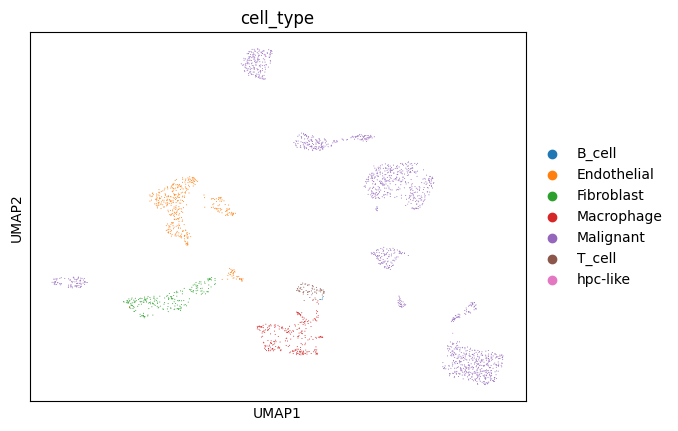

In [5]:
#visualize umap
sc.pl.umap(
    adata,
    color="cell_type",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

Clustering

In [6]:
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

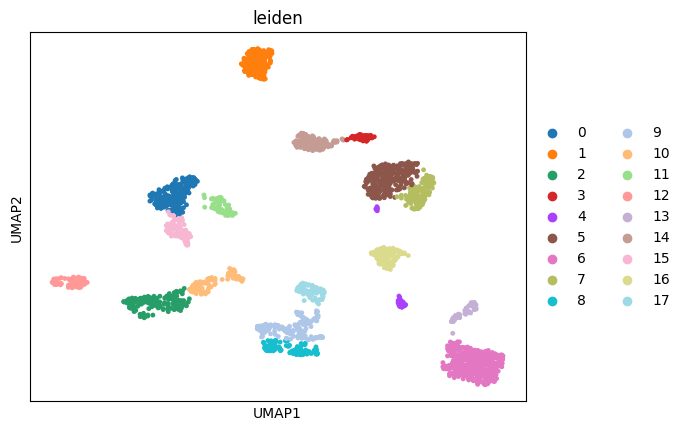

In [7]:
sc.pl.umap(adata, color=["leiden"])

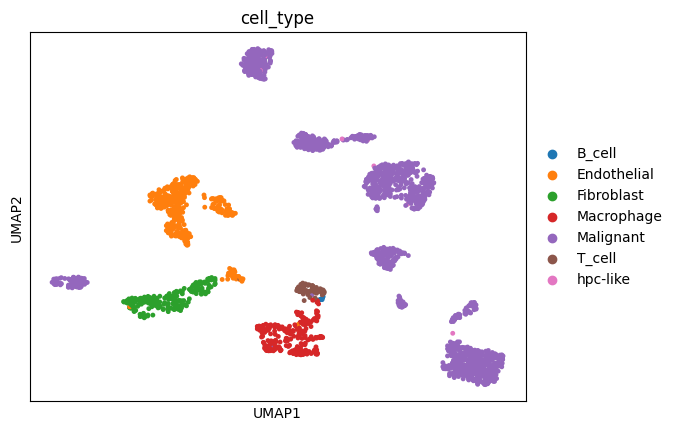

In [8]:
sc.pl.umap(adata, color=["cell_type"])

Marker gene identification

In [9]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

In [10]:
markers_df = sc.get.rank_genes_groups_df(adata, group=None)

In [11]:
B_cell_markers = markers_df[markers_df["group"] == "17"]
endothelial_cell_markers = markers_df[markers_df["group"] == "0"]
Fibroblast_cell_markers = markers_df[markers_df["group"] == "2"]
Macrophage_cell_markers = markers_df[markers_df["group"] == "9"]
Maliganat_cell_markers = pd.concat([markers_df[markers_df["group"] == g] for g in ["6", "13", "16", "7", "5", "3", "14", "1"]])
hpc_cell_markers = markers_df[markers_df["group"] == "3"]

In [12]:
print(f"B_cell_markers: {list(B_cell_markers.head(20)['names'])}")
print(f"endothelial_cell_markers: {list(endothelial_cell_markers.head(20)['names'])}")
print(f"Fibroblast_cell_markers: {list(Fibroblast_cell_markers.head(20)['names'])}")
print(f"Macrophage_cell_markers: {list(Macrophage_cell_markers.head(20)['names'])}")
print(f"Maliganat_cell_markers: {list(Maliganat_cell_markers.head(20)['names'])}")
print(f"hpc_cell_markers: {list(hpc_cell_markers.head(20)['names'])}")

B_cell_markers: ['CORO1A', 'CD52', 'B2M', 'RAC2', 'TMSB4X', 'CXCR4', 'CD2', 'HCST', 'HLA-B', 'PTPRC', 'CD3D', 'SRGN', 'LSP1', 'IL2RG', 'RGS1', 'RPLP1', 'ARHGDIB', 'GMFG', 'RPSA', 'CD3E']
endothelial_cell_markers: ['GNG11', 'PLVAP', 'RAMP3', 'HLA-E', 'VAMP5', 'HSPG2', 'RAMP2', 'DNASE1L3', 'PLPP3', 'ENG', 'EMCN', 'CLEC14A', 'SLC2A3', 'TCF4', 'TGFBR2', 'TM4SF18', 'EGFL7', 'PLPP1', 'SPRY1', 'ZFP36']
Fibroblast_cell_markers: ['ACTA2', 'MYL9', 'TAGLN', 'TPM2', 'CALD1', 'FRZB', 'MFGE8', 'TPM1', 'SPARCL1', 'BGN', 'PGF', 'PPP1R14A', 'NDUFA4L2', 'TINAGL1', 'MYL6', 'SEPTIN4', 'MYLK', 'SPARC', 'PTN', 'SH3BGRL']
Macrophage_cell_markers: ['HLA-DRA', 'HLA-DPB1', 'CD74', 'HLA-DRB1', 'HLA-DPA1', 'AIF1', 'CST3', 'HLA-DQB1', 'SRGN', 'TYROBP', 'FCER1G', 'LST1', 'HLA-DMA', 'PLAUR', 'LAPTM5', 'TMSB4X', 'SAT1', 'HLA-DRB5', 'CD83', 'CTSS']
Maliganat_cell_markers: ['C19orf33', 'S100P', 'S100A6', 'LAMTOR4', 'ARPC1A', 'ARPC1B', 'GNB2', 'RPL8', 'KRT19', 'ATP5MF', 'RPLP2', 'GSTP1', 'SMIM22', 'SEM1', 'EZR', 'CEACAM

Calculate Adjusted Rand Index for clustering labels and true annotations

In [13]:
ari(adata.obs["cell_type"], adata.obs["leiden"])

0.22142418345720233